In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')


In [28]:
# Đọc dữ liệu từ file CSV 
df = pd.read_csv("food_prediction_2016_from_2014.csv", sep=',')
df.head()

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,target_food_2016
0,10010000400815,1,5,1,35,1,1,3.0,1310.0,0.0,...,2.0,2.0,980,150,0,9876,592600.0,297600.0,295000,24578.0
1,10010002802514,1,5,2,63,1,1,1.0,600.0,0.0,...,2.0,2.0,1500,200,150,3760,225650.0,181500.0,44000,11518.0
2,10020006701613,1,5,1,53,1,1,1.0,950.0,0.0,...,2.0,2.0,870,100,0,4698,281894.0,69500.0,6800,7707.0
3,10040013903013,1,1,1,54,1,1,NaN,NaN,NaN,...,2.0,2.0,300,0,0,9541,114500.0,98000.0,16500,4821.0
4,10050016703013,1,2,1,65,25,1,2.0,600.0,0.0,...,2.0,2.0,100,30,0,15340,368180.0,330180.0,38000,5480.7


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            1635 non-null   int64  
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1211 non-null   float64
 8   outpatient_cost       1100 non-null   float64
 9   inpatient_visits      1211 non-null   float64
 10  inpatient_cost        387 non-null    float64
 11  insurance_premium     849 non-null    float64
 12  insurance_outpatient  1507 non-null   float64
 13  insurance_inpatient   1507 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [30]:
df.isnull().sum()


h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1                 0
area_type2                 0
outpatient_visits        424
outpatient_cost          535
inpatient_visits         424
inpatient_cost          1248
insurance_premium        786
insurance_outpatient     128
insurance_inpatient      128
medicine_cost              0
equipment_cost             0
health_subsidy             0
thubq                      0
thunhap                    0
salary                     0
other_income               0
target_food_2016           0
dtype: int64

In [31]:
# Fill missing values for continuous variables with mean (only keep columns that exist)
numerical_cols = ['outpatient_visits', 'outpatient_cost', 'inpatient_visits', 'inpatient_cost',
                  'insurance_premium']
numerical_cols = [col for col in numerical_cols if col in df.columns]

for col in numerical_cols:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

# Fill missing values for categorical-like variables with mode (only if they exist)
categorical_cols = ['insurance_outpatient', 'insurance_inpatient']
categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in categorical_cols:
    modes = df[col].mode()
    if not modes.empty:
        df[col].fillna(modes.iloc[0], inplace=True)
    else:
        df[col].fillna(0, inplace=True)

# Quick check
print("Missing values after imputation:")
print(df[numerical_cols + categorical_cols].isnull().sum())

Missing values after imputation:
outpatient_visits       0
outpatient_cost         0
inpatient_visits        0
inpatient_cost          0
insurance_premium       0
insurance_outpatient    0
insurance_inpatient     0
dtype: int64


In [32]:
summary = df.describe(include='all')
summary

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,...,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thubq,thunhap,salary,other_income,target_food_2016
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,...,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.793884,1.236697,51.395107,45.476453,1.014679,2.529315,982.081818,0.263419,...,1.751070,1.923547,816.387156,56.911927,737.585321,2548.612232,1.110556e+05,48243.047095,1.198320e+04,4841.603547
std,2.775770e+14,27.488299,1.565685,0.425185,13.925109,26.949177,0.147703,2.996705,2927.891568,0.572188,...,0.432525,0.265802,1828.829267,275.759382,4087.083086,3060.650039,1.323976e+05,69381.575954,4.596503e+04,4606.518367
min,1.001000e+13,1.000000,1.000000,1.000000,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,194.000000,3.530000e+03,0.000000,0.000000e+00,376.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,41.000000,26.000000,1.000000,1.000000,120.000000,0.000000,...,2.000000,2.000000,200.000000,0.000000,0.000000,1139.500000,4.708200e+04,0.000000,5.500000e+02,2470.000000
50%,4.445519e+14,44.000000,4.000000,1.000000,50.000000,40.000000,1.000000,2.000000,680.000000,0.000000,...,2.000000,2.000000,360.000000,0.000000,0.000000,1906.000000,8.345000e+04,24960.000000,2.460000e+03,3800.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,59.500000,68.000000,1.000000,2.529315,982.081818,0.263419,...,2.000000,2.000000,720.000000,50.000000,0.000000,3064.000000,1.377930e+05,69420.000000,8.935000e+03,5969.000000
max,9.697332e+14,96.000000,13.000000,2.000000,97.000000,99.000000,3.000000,48.000000,72000.000000,7.000000,...,2.000000,2.000000,35000.000000,8690.000000,105000.000000,68058.000000,2.646980e+06,654000.000000,1.035000e+06,92958.000000


In [33]:
# Mã hóa biến định tính bằng LabelEncoder
le = LabelEncoder()
for col in ['tinh', 'head_gender', 'area_type2', 'insurance_outpatient', 'insurance_inpatient']:
    df[col] = le.fit_transform(df[col])

# Kiểm tra phân phối biến mục tiêu
print("\nPhân phối biến mục tiêu target_food_2016:")
print(df['target_food_2016'].describe())


Phân phối biến mục tiêu target_food_2016:
count     1635.000000
mean      4841.603547
std       4606.518367
min        376.000000
25%       2470.000000
50%       3800.000000
75%       5969.000000
max      92958.000000
Name: target_food_2016, dtype: float64



Tầm quan trọng của các đặc trưng:
                Variable  Importance
17               thunhap    0.280382
18                salary    0.093450
13         medicine_cost    0.084173
19          other_income    0.081121
1         household_size    0.076562
16                 thubq    0.061575
7        outpatient_cost    0.048244
4             area_type1    0.042001
3               head_age    0.037274
15        health_subsidy    0.037002
10     insurance_premium    0.032189
6      outpatient_visits    0.032069
0                   tinh    0.031563
14        equipment_cost    0.024015
9         inpatient_cost    0.012530
12   insurance_inpatient    0.008766
11  insurance_outpatient    0.007294
8       inpatient_visits    0.005364
2            head_gender    0.003863
5             area_type2    0.000564


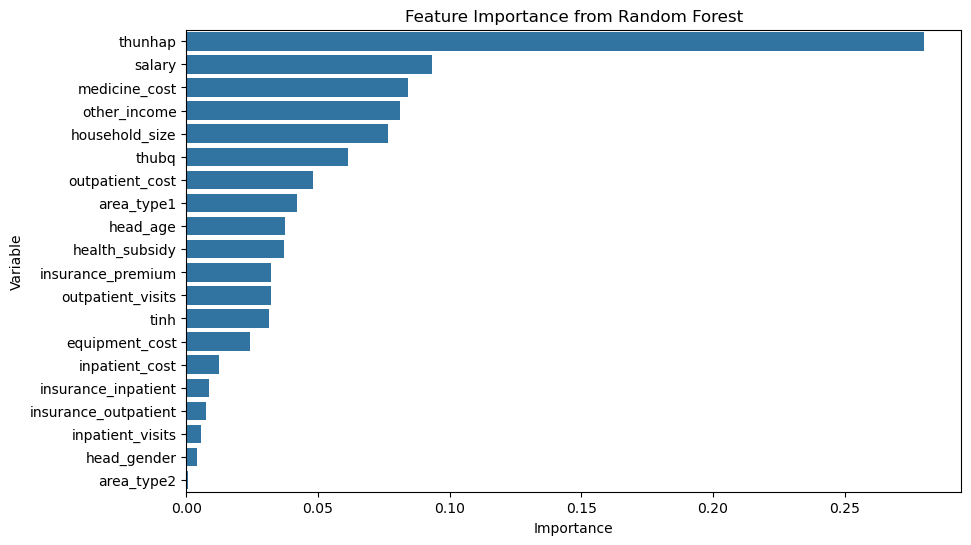


Các biến quan trọng được giữ lại: ['thunhap', 'salary', 'medicine_cost', 'other_income', 'household_size', 'thubq']


,thunhap,salary,medicine_cost,other_income,household_size,thubq,target_food_2016
0,592600.0,297600.0,980,295000,5,9876,24578.0
1,225650.0,181500.0,1500,44000,5,3760,11518.0
2,281894.0,69500.0,870,6800,5,4698,7707.0
3,114500.0,98000.0,300,16500,1,9541,4821.0
4,368180.0,330180.0,100,38000,2,15340,5480.7


In [34]:
# Sử dụng Random Forest để đánh giá tầm quan trọng của các đặc trưng
X = df.drop(['target_food_2016', 'h_code'], axis=1)
y = df['target_food_2016']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Tầm quan trọng của các đặc trưng
feature_importance = pd.DataFrame({'Variable': X.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng của các đặc trưng:")
print(feature_importance)

# Vẽ biểu đồ tầm quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

# Chọn các biến quan trọng (giữ lại các biến có tầm quan trọng > 0.06
important_features = feature_importance[feature_importance['Importance'] > 0.06]['Variable'].tolist()
print("\nCác biến quan trọng được giữ lại:", important_features)

# Tạo DataFrame mới chỉ chứa các biến quan trọng và target_food_2016
df = df[important_features + ['target_food_2016']]
df.head()


In [35]:
#  Tách features (X) và target (y)
continuous_vars = []
discrete_vars = []

for col in df.columns:
    if col != 'target_food_2016':
        if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 15:
            continuous_vars.append(col)
        else:
            discrete_vars.append(col)

print("\nBiến liên tục:", continuous_vars)
print("Biến rời rạc:", discrete_vars)


Biến liên tục: ['thunhap', 'salary', 'medicine_cost', 'other_income', 'thubq']
Biến rời rạc: ['household_size']


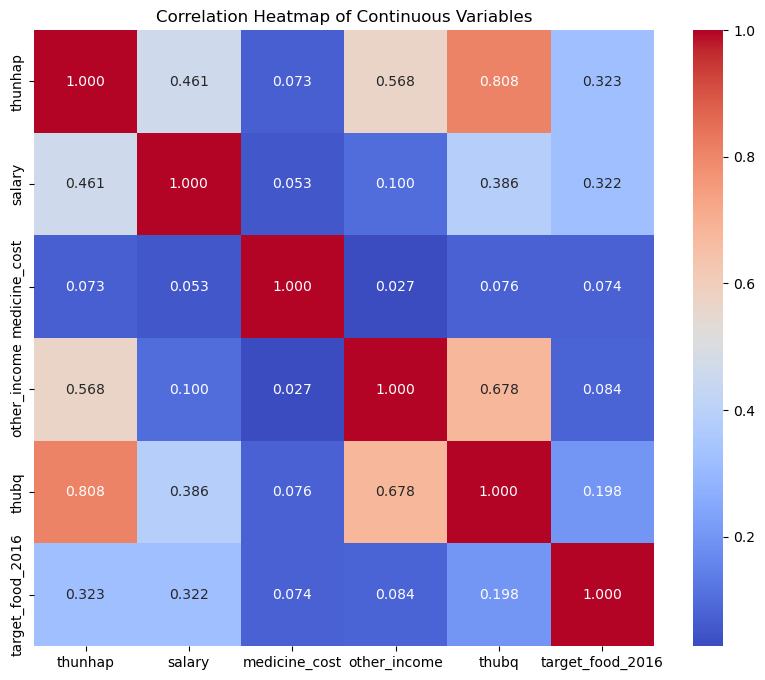

In [36]:
# Phân tích biến liên tục: Heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(df[continuous_vars + ['target_food_2016']].corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap of Continuous Variables')
plt.show()

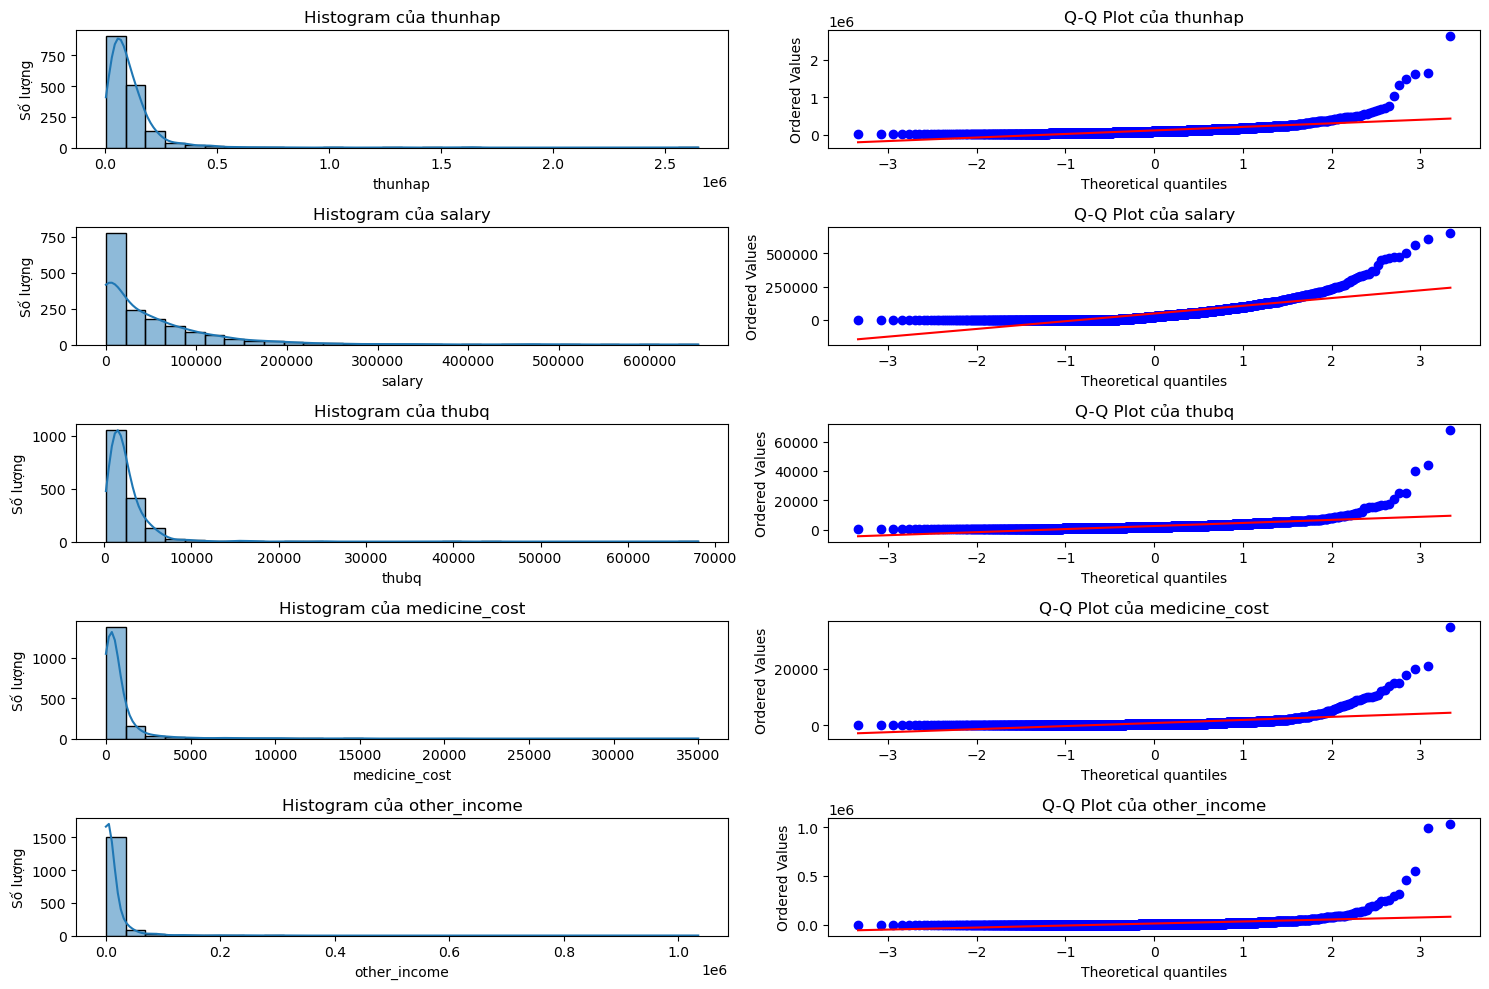


Kiểm định Shapiro-Wilk cho thunhap:
Statistic: 0.5167, p-value: 5.6086e-55
thunhap KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho salary:
Statistic: 0.6953, p-value: 2.3350e-47
salary KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho thubq:
Statistic: 0.4681, p-value: 1.2433e-56
thubq KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho medicine_cost:
Statistic: 0.3572, p-value: 5.6154e-60
medicine_cost KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).

Kiểm định Shapiro-Wilk cho other_income:
Statistic: 0.2064, p-value: 8.0811e-64
other_income KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).


In [37]:

from scipy.stats import shapiro, probplot

# Danh sách các biến liên tục
continuous_vars = ['thunhap', 'salary', 'thubq', 'medicine_cost', 'other_income']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(15, 10))
# Kiểm tra phân phối chuẩn cho từng biến
for i, var in enumerate(continuous_vars, 1):
    # 1. Histogram
    plt.subplot(len(continuous_vars), 2, 2*i-1)
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f'Histogram của {var}')
    plt.xlabel(var)
    plt.ylabel('Số lượng')

    # 2. Q-Q Plot
    plt.subplot(len(continuous_vars), 2, 2*i)
    probplot(df[var], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot của {var}')

plt.tight_layout()
plt.show()

# 3. Kiểm định Shapiro-Wilk
for var in continuous_vars:
    stat, p_value = shapiro(df[var])
    print(f'\nKiểm định Shapiro-Wilk cho {var}:')
    print(f'Statistic: {stat:.4f}, p-value: {p_value:.4e}')
    if p_value < 0.05:
        print(f'{var} KHÔNG tuân theo phân phối chuẩn (p-value < 0.05).')
    else:
        print(f'{var} có thể tuân theo phân phối chuẩn (p-value >= 0.05).')


Biến đổi cho biến không chuẩn: thunhap

Sau log transform:
Shapiro-Wilk: Statistics=0.987, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.886, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.991, p-value=0.000


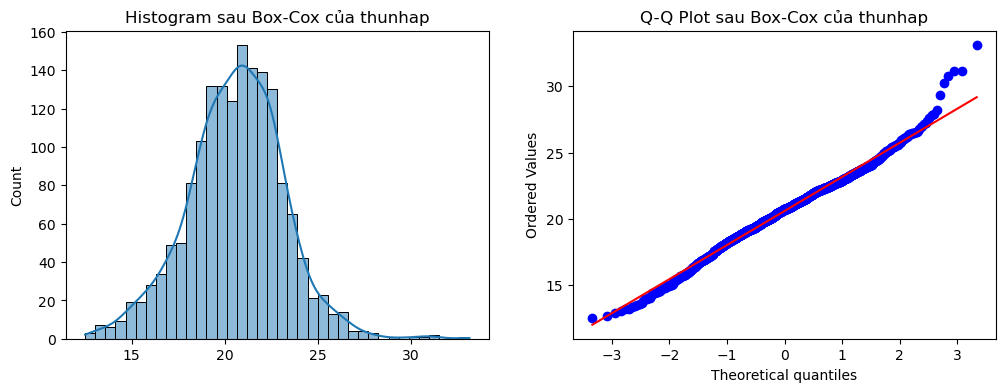


Biến đổi cho biến không chuẩn: salary

Sau log transform:
Shapiro-Wilk: Statistics=0.720, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.899, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.809, p-value=0.000


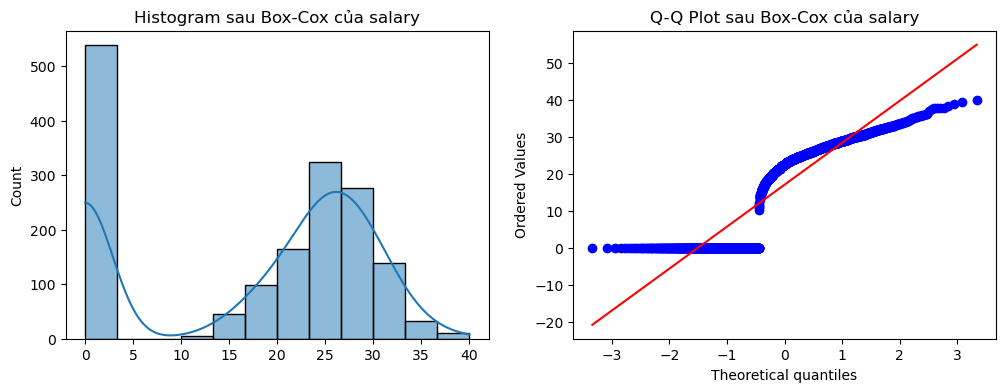


Biến đổi cho biến không chuẩn: thubq

Sau log transform:
Shapiro-Wilk: Statistics=0.994, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.855, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.995, p-value=0.000


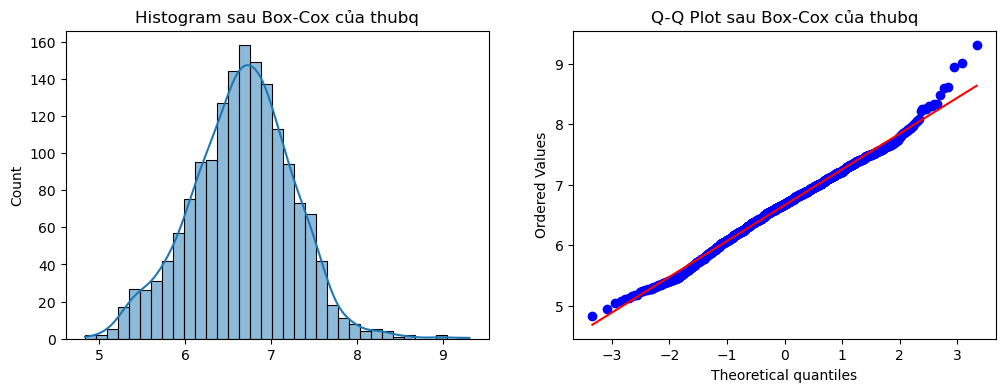


Biến đổi cho biến không chuẩn: medicine_cost

Sau log transform:
Shapiro-Wilk: Statistics=0.816, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.764, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.935, p-value=0.000


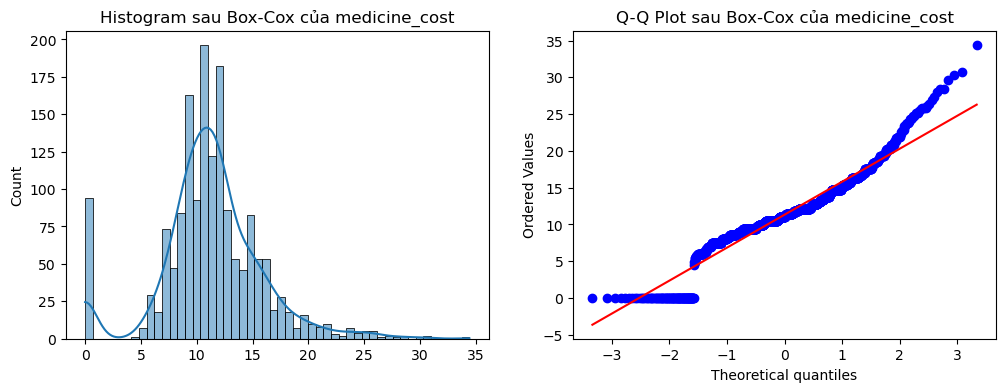


Biến đổi cho biến không chuẩn: other_income

Sau log transform:
Shapiro-Wilk: Statistics=0.876, p-value=0.000

Sau sqrt transform:
Shapiro-Wilk: Statistics=0.704, p-value=0.000

Sau boxcox transform:
Shapiro-Wilk: Statistics=0.976, p-value=0.000


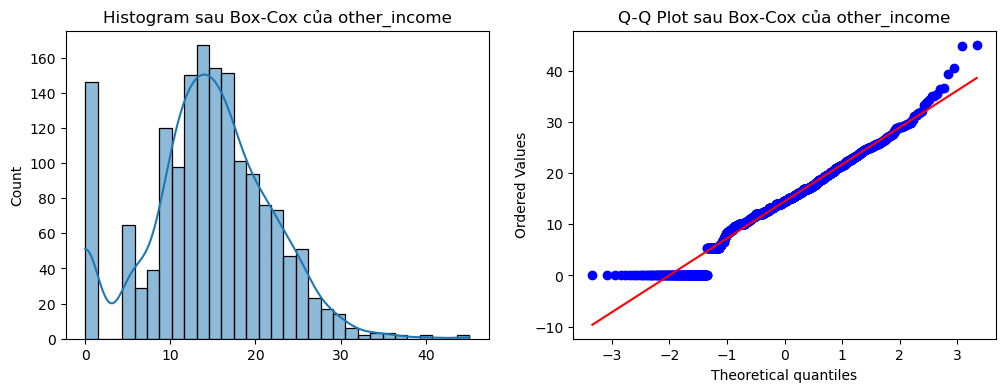

,thunhap,salary,medicine_cost,other_income,household_size,thubq,target_food_2016,thunhap_boxcox,salary_boxcox,thubq_boxcox,medicine_cost_boxcox,other_income_boxcox
0,592600.0,297600.0,980,295000,5,9876,24578.0,27.245384,35.063549,7.930406,14.549406,36.395029
1,225650.0,181500.0,1500,44000,5,3760,11518.0,23.874094,32.211815,7.206535,16.254179,25.876978
2,281894.0,69500.0,870,6800,5,4698,7707.0,24.623215,27.215480,7.375539,14.097515,18.048259
3,114500.0,98000.0,300,16500,1,9541,4821.0,21.688325,28.926477,7.904935,10.494177,21.498540
4,368180.0,330180.0,100,38000,2,15340,5480.7,25.543851,35.688506,8.252895,7.493802,25.181857


In [38]:
# Hàm biến đổi và kiểm tra lại
from scipy import stats
from scipy.stats import boxcox


def transform_and_check(df, var):
    print(f"\nBiến đổi cho biến không chuẩn: {var}")
    
    # Xử lý giá trị âm/zero 
    if (df[var] <= 0).any():
        shifted = df[var] - df[var].min() + 1 
    else:
        shifted = df[var]
    
    # Thử các biến đổi
    transformations = {
        'log': np.log(shifted),  # Log transform (cho skew positive)
        'sqrt': np.sqrt(shifted)  # Square root (cho skew moderate)
    }
    
    # Thử Box-Cox (cần giá trị dương và không phải hằng số)
    try:
        boxcox_transformed = boxcox(shifted)[0]
        transformations['boxcox'] = boxcox_transformed
    except Exception as e:
        # Nếu Box-Cox thất bại , in thông báo và dùng shifted làm fallback
        print(f"Box-Cox failed for {var}: {e}")
        transformations['boxcox'] = shifted
    
    # Kiểm tra normality sau từng biến đổi
    for trans_name, trans_data in transformations.items():
        print(f"\nSau {trans_name} transform:")
        try:
            stat, p = stats.shapiro(trans_data)
            print(f'Shapiro-Wilk: Statistics={stat:.3f}, p-value={p:.3f}')
            if p > 0.05:
                print("Bây giờ gần chuẩn hơn!")
        except Exception as e:
            print(f"Shapiro-Wilk test failed for {var} after {trans_name}: {e}")
            continue
        
        # Visualize sau transform 
        if trans_name == 'boxcox':
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            sns.histplot(trans_data, kde=True)
            plt.title(f'Histogram sau Box-Cox của {var}')
            
            plt.subplot(1, 2, 2)
            stats.probplot(trans_data, dist="norm", plot=plt)
            plt.title(f'Q-Q Plot sau Box-Cox của {var}')
            plt.show()
    
    # Lưu biến đổi tốt nhất vào df mới
    df[var + '_boxcox'] = transformations['boxcox']
    return df

# Áp dụng cho các biến không chuẩn
non_normal_vars = ['thunhap','salary', 'thubq', 'medicine_cost', 'other_income'] 
for var in non_normal_vars:
    df = transform_and_check(df, var)

# Xem data sau biến đổi
df.head()

Linear Regression - MSE: 12557245.63, R2: 0.23
Random Forest - MSE: 14737690.24, R2: 0.10
Mean chi tiêu thức ăn thực tế (2016): 4841.60
Mean chi tiêu thức ăn dự đoán (dựa trên 2014): 5032.87


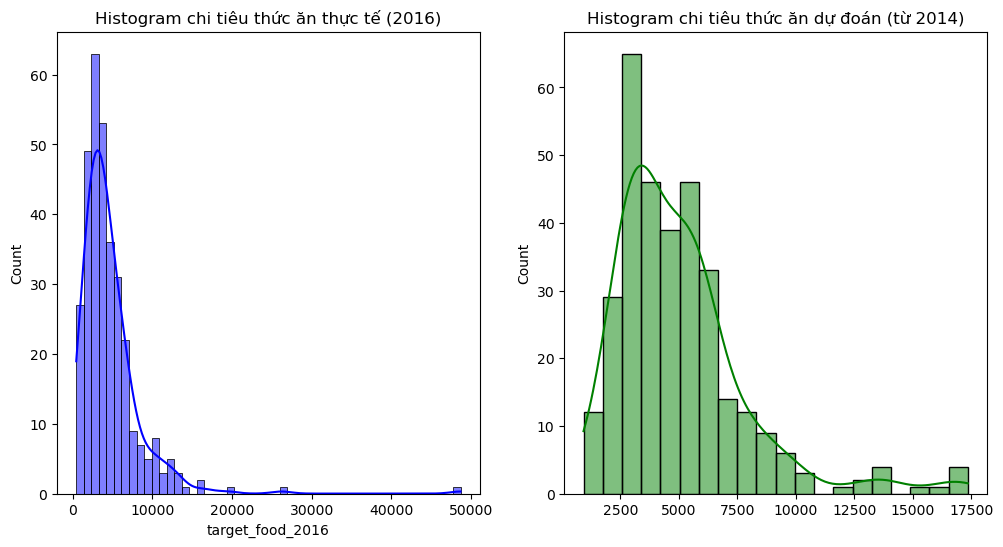


Kết luận dựa trên dữ liệu (dự đoán cho cả nước):
Nhu cầu chi tiêu thức ăn dự kiến tăng so với thực tế, nên khuyến nghị sản xuất thêm để đáp ứng nhu cầu cho cả nước.
Lý do: Dựa trên mô hình dự đoán từ dữ liệu 2014, mean chi tiêu thức ăn ước tính cho 2016 là 5032.87, so với thực tế 4841.60.


In [39]:
from scipy.stats import boxcox
boxcox_vars = ['salary', 'other_income', 'medicine_cost', 'thunhap', 'thubq']
for v in boxcox_vars:
    col_name = v + '_boxcox'
    if col_name not in df.columns:
        shifted = df[v].copy()
        if (shifted <= 0).any():
            shifted = shifted - shifted.min() + 1
        df[col_name] = boxcox(shifted)[0]

#  DANH SÁCH FEATURES 
features = [
    'tinh_boxcox', 'thubq_boxcox', 'thunhap_boxcox', 'salary_boxcox', 'other_income_boxcox', 'medicine_cost_boxcox'
]

target = 'target_food_2016'

# Kiểm tra các feature thực sự tồn tại trong df và loại bỏ những feature mất do các bước trước đó
available_features = [col for col in features if col in df.columns]
missing_features = [col for col in features if col not in df.columns]
if missing_features:
    print("Warning: các feature sau không tồn tại trong df và sẽ bị loại bỏ:", missing_features)

# Đảm bảo target tồn tại
if target not in df.columns:
    raise KeyError(f"Target '{target}' không tồn tại trong DataFrame hiện tại.")

# Nếu không còn feature nào sau khi lọc thì dừng lại
if len(available_features) == 0:
    raise ValueError("Không có feature nào hợp lệ để huấn luyện. Kiểm tra lại các bước tiền xử lý trước đó.")

# Chia dữ liệu thành train và test (80/20)
X = df[available_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train mô hình Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán trên test set
y_pred_lr = lr_model.predict(X_test)

# Đánh giá mô hình
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MSE: {mse_lr:.2f}, R2: {r2_lr:.2f}")

# Train mô hình Random Forest Regressor 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán trên test set
y_pred_rf = rf_model.predict(X_test)

# Đánh giá mô hình
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MSE: {mse_rf:.2f}, R2: {r2_rf:.2f}")

# Sử dụng Random Forest 
y_pred = y_pred_rf 

# Tính mean của target thực tế và dự đoán
mean_actual = y.mean()
mean_predicted = pd.Series(y_pred).mean()  

print(f"Mean chi tiêu thức ăn thực tế (2016): {mean_actual:.2f}")
print(f"Mean chi tiêu thức ăn dự đoán (dựa trên 2014): {mean_predicted:.2f}")

# Vẽ histogram để so sánh phân bố
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(y_test, kde=True, color='blue')
plt.title('Histogram chi tiêu thức ăn thực tế (2016)')

plt.subplot(1, 2, 2)
sns.histplot(y_pred, kde=True, color='green')
plt.title('Histogram chi tiêu thức ăn dự đoán (từ 2014)')
plt.show()

# Decision dựa trên mean: Nếu mean dự đoán > mean thực tế, có thể nhu cầu tăng -> cần sản xuất thêm
# Ngược lại, nhu cầu giảm -> có thể dự trữ
if mean_predicted > mean_actual:
    decision = "Nhu cầu chi tiêu thức ăn dự kiến tăng so với thực tế, nên khuyến nghị sản xuất thêm để đáp ứng nhu cầu cho cả nước."
else:
    decision = "Nhu cầu chi tiêu thức ăn dự kiến giảm hoặc ổn định, nên tập trung vào dự trữ đồ ăn để tránh lãng phí."

print("\nKết luận dựa trên dữ liệu (dự đoán cho cả nước):")
print(decision)
print("Lý do: Dựa trên mô hình dự đoán từ dữ liệu 2014, mean chi tiêu thức ăn ước tính cho 2016 là {:.2f}, so với thực tế {:.2f}.".format(mean_predicted, mean_actual))